<a href="https://colab.research.google.com/github/Jenifar5/Applied-ai/blob/main/IMAGE_TRANSFORMER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready.

Upload any image...


Saving pic4.jpg to pic4 (1).jpg


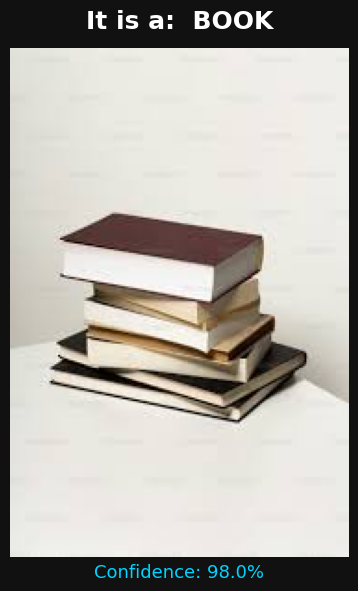

It is a: book  (98.0% confidence)


In [12]:

# !pip install transformers torch torchvision pillow

from transformers import CLIPProcessor, CLIPModel
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch
import io

print("Loading CLIP model...")
model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("Model ready.\n")

print("Upload any image...")
uploaded = files.upload()

candidates = [
    "a cat", "a dog", "a car", "a bike", "a bus", "a truck",
    "a bird", "a horse", "a cow", "a elephant", "a lion", "a tiger",
    "a person", "a tree", "a flower", "a mountain", "a beach",
    "a building", "a bridge", "a road", "a river", "a sky",
    "a pizza", "a burger", "a cake", "a fruit", "a vegetable",
    "a phone", "a laptop", "a chair", "a table", "a bottle",
    "a boat", "a train", "a airplane", "a helicopter",
    "a fish", "a snake", "a frog", "a rabbit", "a bear",
    "a book", "a clock", "a cup", "a ball", "a bag"
]

for fname, fbytes in uploaded.items():
    img = Image.open(io.BytesIO(fbytes)).convert("RGB")

    inputs = processor(text=candidates, images=img, return_tensors="pt", padding=True)
    with torch.no_grad():
        probs = model(**inputs).logits_per_image.softmax(dim=1)[0]

    top_idx    = probs.argmax().item()
    label      = candidates[top_idx].replace("a ", "").replace("an ", "")
    confidence = probs[top_idx].item() * 100

    # Show only the image with prediction label
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor("#111111")
    ax.imshow(img)
    ax.set_title(f"It is a:  {label.upper()}",
                 color="white", fontsize=18, fontweight='bold', pad=14)
    ax.text(0.5, -0.04, f"Confidence: {confidence:.1f}%",
            transform=ax.transAxes, ha='center', color="#00d4ff", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"It is a: {label}  ({confidence:.1f}% confidence)")
